# **Future‑Proofing Solar Energy: A Multi‑Model Assessment of Climate Change Impacts on Photovoltaic Site Suitability Using Supportive Statistical Learning**

# 1. Setup and Library Imports

We begin by importing all the Python libraries we need. Each library has a specific job:
- `numpy` and `pandas` for handling data.
- `matplotlib` and `seaborn` for making charts.
- `scipy.stats` for statistical tests.
- `statsmodels` for ANOVA and regression.
- `sklearn` for machine learning (logistic regression, clustering, decision tree).
- `libpysal` and `esda` for checking spatial patterns (optional).

In [24]:
# Install any missing libraries (uncomment if needed)
# !pip install geopandas rasterio cartopy plotly scikit-learn statsmodels libpysal esda -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.ndimage import gaussian_filter
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Optional: for spatial autocorrelation test
try:
    from libpysal.weights import DistanceBand
    from esda.moran import Moran
    spatial_test_available = True
except ImportError:
    spatial_test_available = False
    print("Note: libpysal and esda not installed. Spatial autocorrelation test will be skipped.")

# Set random seed for reproducibility (so you get the same results every time)
np.random.seed(42)

# 2. Prepare a Realistic Test Dataset

We create a pretend study area of 100×100 grid cells (10,000 locations) covering about 200 km × 200 km.  
Each location gets realistic values for:
- **Elevation** (meters)
- **Land cover** (water, forest, agriculture, barren, urban)
- **Protected area** (yes/no)
- **Distance to electricity grid** (km)
- **Current and future solar irradiance** (kWh/m²/day)
- **Current and future temperature** (°C)
- **Policy zone** (1 if near a big city, else 0)

All numbers are made to look like real data by including **spatial patterns** (nearby places are similar) and realistic relationships (e.g., temperature drops with elevation). This helps us test our methods before using real data.

In [25]:
# Define grid parameters
n_cells = 10000  # 100 x 100 grid
grid_size = 100
lons = np.linspace(88.0, 90.0, grid_size)   # longitude around Kolkata
lats = np.linspace(22.0, 24.0, grid_size)   # latitude
lon_grid, lat_grid = np.meshgrid(lons, lats)
lon = lon_grid.flatten()
lat = lat_grid.flatten()

# ---- Function to create spatially smooth fields ----
def generate_spatial_field(mean, variance, range_param, grid_shape, seed=None):
    """Generate a smoothly varying random field."""
    if seed is not None:
        np.random.seed(seed)
    field = np.random.normal(0, 1, grid_shape)
    sigma = range_param * grid_shape[0]  # how far the influence reaches
    field_smooth = gaussian_filter(field, sigma=sigma, mode='wrap')
    field_smooth = (field_smooth - field_smooth.mean()) / field_smooth.std()
    field_smooth = field_smooth * np.sqrt(variance) + mean
    return field_smooth.flatten()

grid_shape = (grid_size, grid_size)

# 1. Elevation
elev_field = generate_spatial_field(mean=300, variance=20000, range_param=0.2,
                                    grid_shape=grid_shape, seed=1)
elevation = np.clip(elev_field, 0, 800)

# 2. Land cover (categorical, depends on elevation)
landcover_probs = np.zeros((n_cells, 5))
for i in range(n_cells):
    if elevation[i] < 100:
        landcover_probs[i] = [0.6, 0.1, 0.2, 0.05, 0.05]   # water, forest, agri, barren, urban
    elif elevation[i] < 300:
        landcover_probs[i] = [0.1, 0.3, 0.4, 0.1, 0.1]
    else:
        landcover_probs[i] = [0.05, 0.5, 0.2, 0.2, 0.05]
landcover = np.array([np.random.choice(5, p=probs) for probs in landcover_probs])

# 3. Protected areas (10% random, but not in urban)
protected = np.zeros(n_cells)
for i in range(n_cells):
    if landcover[i] != 4 and np.random.rand() < 0.1:
        protected[i] = 1

# 4. Distance to grid (km) – shorter near cities and lowlands
dist_to_grid = np.random.gamma(2, 10, n_cells) + 5*(landcover==4) + 20*(landcover==0)
dist_to_grid = np.clip(dist_to_grid, 0, 100)

# 5. Current irradiance – higher in elevated areas
irr_current_field = generate_spatial_field(mean=5.0, variance=0.8, range_param=0.3,
                                           grid_shape=grid_shape, seed=2)
irr_current = irr_current_field + 0.3 * (elevation / 500)
irr_current = np.clip(irr_current, 3, 8)

# 6. Future irradiance (2050) – slightly lower on average
irr_change_field = generate_spatial_field(mean=-0.3, variance=0.1, range_param=0.4,
                                          grid_shape=grid_shape, seed=3)
irr_future = irr_current + irr_change_field
irr_future = np.clip(irr_future, 2.5, 7.5)

# 7. Current temperature – decreases with elevation
temp_base = generate_spatial_field(mean=28, variance=4, range_param=0.3,
                                   grid_shape=grid_shape, seed=4)
temp_current = temp_base - 0.005 * elevation + np.random.normal(0, 1, n_cells)
temp_current = np.clip(temp_current, 15, 35)

# 8. Future temperature – warmer
temp_increase = generate_spatial_field(mean=1.8, variance=0.3, range_param=0.5,
                                       grid_shape=grid_shape, seed=5)
temp_future = temp_current + temp_increase
temp_future = np.clip(temp_future, 16, 37)

# 9. Policy zone – near the city centre (Kolkata)
center_lon, center_lat = 89, 23
policy_zone = ((lon - center_lon)**2 + (lat - center_lat)**2 < 0.3).astype(int)

# Put everything into a table (DataFrame)
df = pd.DataFrame({
    'lon': lon,
    'lat': lat,
    'elevation': elevation,
    'landcover': landcover,
    'protected': protected,
    'dist_to_grid': dist_to_grid,
    'irr_current': irr_current,
    'irr_future': irr_future,
    'temp_current': temp_current,
    'temp_future': temp_future,
    'policy_zone': policy_zone
})

# Give landcover numbers meaningful names
landcover_names = {0:'Water', 1:'Forest', 2:'Agriculture', 3:'Barren', 4:'Urban'}
df['landcover_name'] = df['landcover'].map(landcover_names)

print("Data shape:", df.shape)
df.head()

Data shape: (10000, 12)


,lon,lat,elevation,landcover,protected,dist_to_grid,irr_current,irr_future,temp_current,temp_future,policy_zone,landcover_name
0,88.000000,22.0,468.418104,3,0.0,6.730400,6.514703,6.555013,26.084453,28.316631,0,Barren
1,88.020202,22.0,474.017534,0,0.0,22.848662,6.537887,6.570559,25.394689,27.583725,0,Water
2,88.040404,22.0,479.692722,3,0.0,5.112358,6.557285,6.581597,23.997651,26.139874,0,Barren
3,88.060606,22.0,485.431455,1,0.0,14.987750,6.573086,6.588650,24.603856,26.700397,0,Forest
4,88.080808,22.0,491.180080,1,0.0,14.851123,6.584916,6.591525,25.013676,27.065211,0,Forest


# 3. Compute Suitability Scores

We combine five factors into a single **suitability score** (0 = worst, 1 = best) for building solar farms:

- **Irradiance** – more sun is better.
- **Temperature** – cooler is better (panels are less efficient when hot).
- **Slope** – flatter land is cheaper to build on.
- **Distance to grid** – closer to power lines reduces connection cost.
- **Land cover** – some land types (barren, agriculture) are preferred over others (water, forest).

Each factor is first scaled to 0–1. Then we give them different weights (based on expert opinion) and add them up.

We compute two scores:
- `suit_current` – using today's climate.
- `suit_future` – using the projected 2050 climate.

Finally, we also create a simple “suitable / unsuitable” flag based on whether future suitability is above the median.

In [26]:
# Approximate slope from elevation changes
slope = np.abs(elevation - np.roll(elevation, 1)) + np.abs(elevation - np.roll(elevation, -1))
slope = slope / 100.0  # scale to reasonable numbers

# Function to normalise a column to 0..1
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# For factors where lower is better, we invert them (1 - normalised)
irr_current_n = normalize(irr_current)
irr_future_n = normalize(irr_future)
temp_current_n = 1 - normalize(temp_current)
temp_future_n = 1 - normalize(temp_future)
slope_n = 1 - normalize(slope)
dist_n = 1 - normalize(dist_to_grid)

# Land cover suitability (expert judgement)
landcover_weights = np.array([0.0, 0.3, 0.6, 0.8, 0.2])  # water, forest, agri, barren, urban
landcover_n = landcover_weights[landcover]

# Weights for each factor (they add up to 1)
w_irr = 0.35
w_temp = 0.25
w_slope = 0.15
w_dist = 0.15
w_land = 0.10

# Current suitability
df['suit_current'] = (w_irr * irr_current_n +
                      w_temp * temp_current_n +
                      w_slope * slope_n +
                      w_dist * dist_n +
                      w_land * landcover_n)

# Future suitability
df['suit_future'] = (w_irr * irr_future_n +
                     w_temp * temp_future_n +
                     w_slope * slope_n +
                     w_dist * dist_n +
                     w_land * landcover_n)

# Binary classification: 1 if future suitability > median, else 0
threshold = df['suit_future'].median()
df['suitable_future_binary'] = (df['suit_future'] > threshold).astype(int)

print("Suitability scores computed.")
df[['suit_current', 'suit_future', 'suitable_future_binary']].describe()

Suitability scores computed.


,suit_current,suit_future,suitable_future_binary
count,10000.000000,10000.000000,10000.000000
mean,0.535982,0.529086,0.500000
std,0.129961,0.125571,0.500025
min,0.091677,0.086068,0.000000
25%,0.439038,0.439666,0.000000
50%,0.542501,0.532552,0.500000
75%,0.639786,0.626579,1.000000
max,0.847079,0.836807,1.000000


# 4. Explore the Data

Before any fancy statistics, we look at the data with simple plots:
- **Histograms** to see the shape of each variable.
- **Correlation matrix** to see how variables are related.
- **Maps** to see where high and low suitability are located.

These plots help us understand what we're working with and catch any obvious problems.

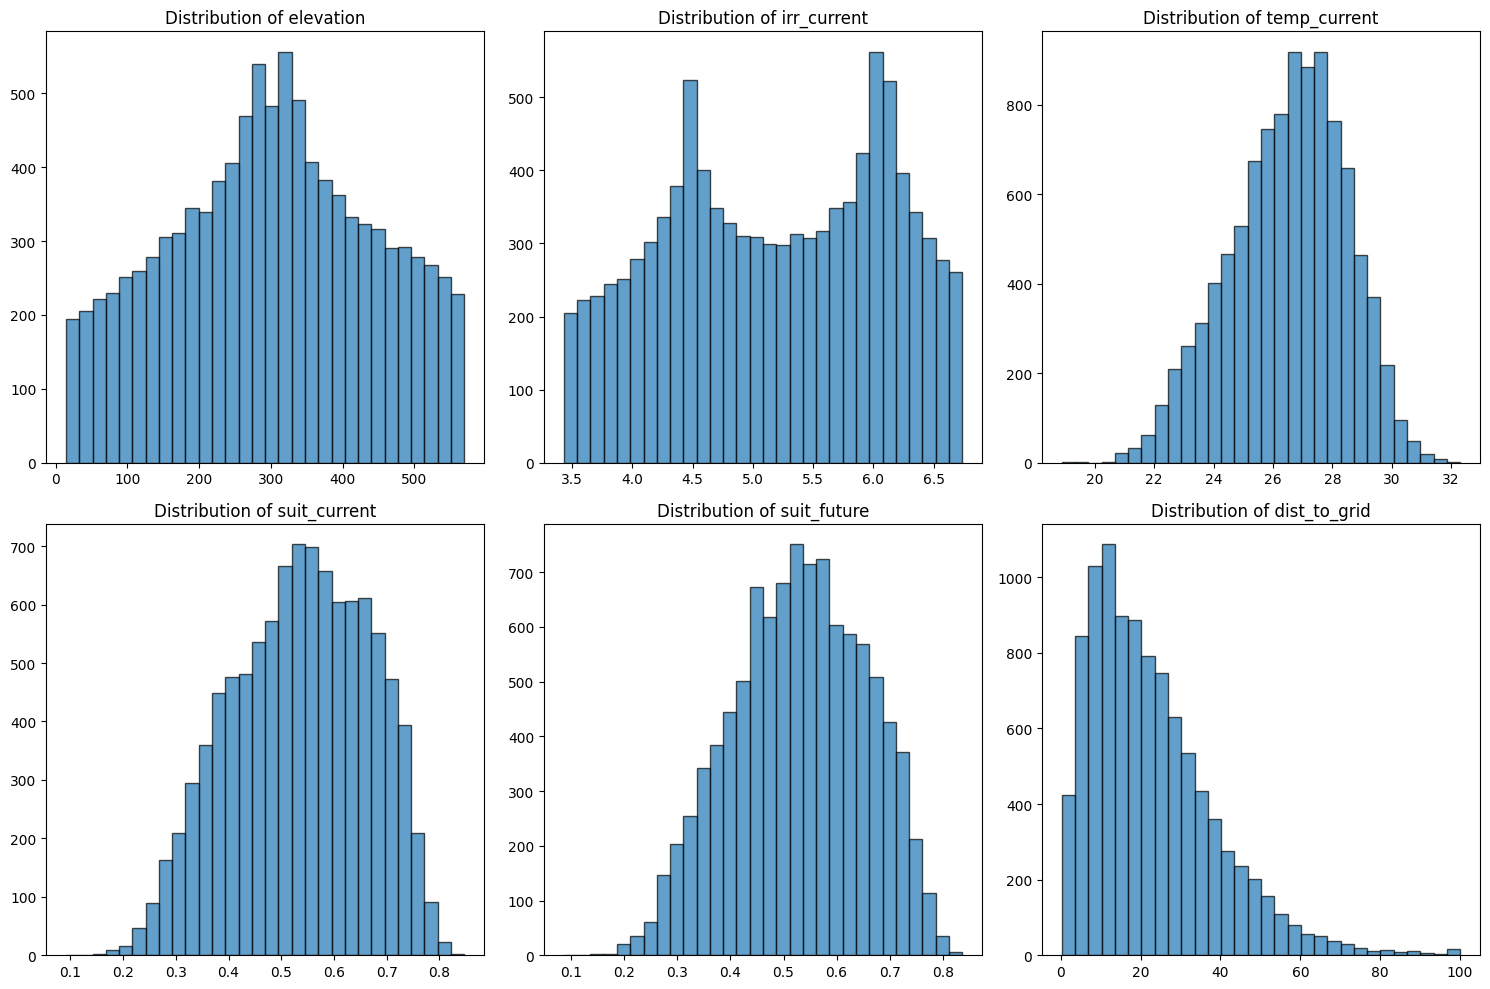

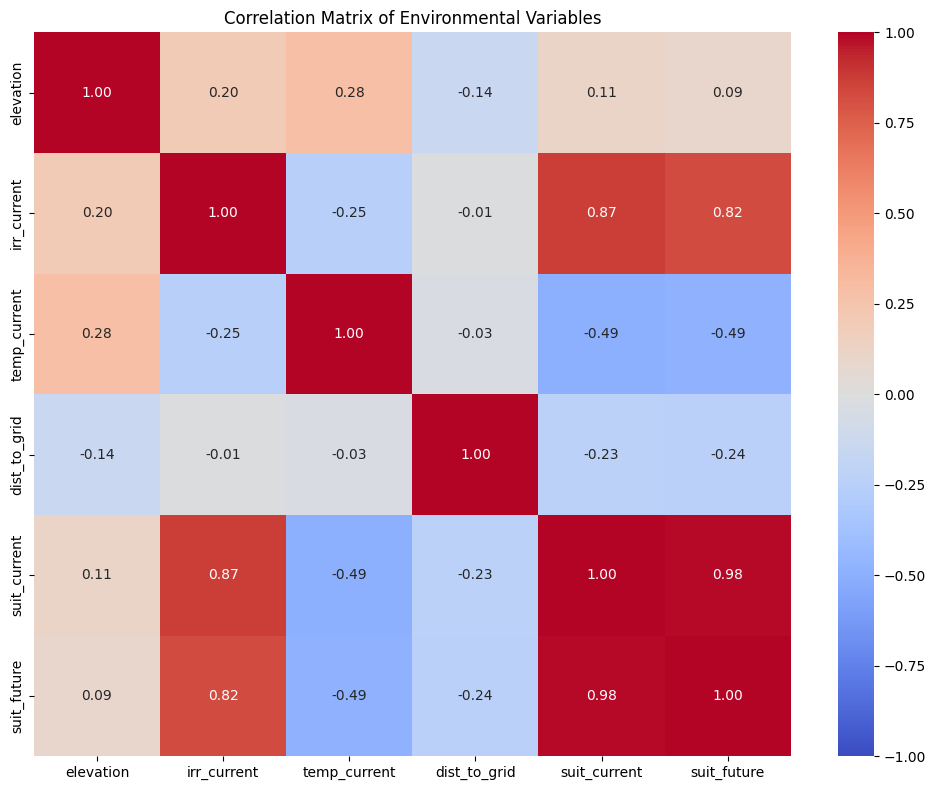

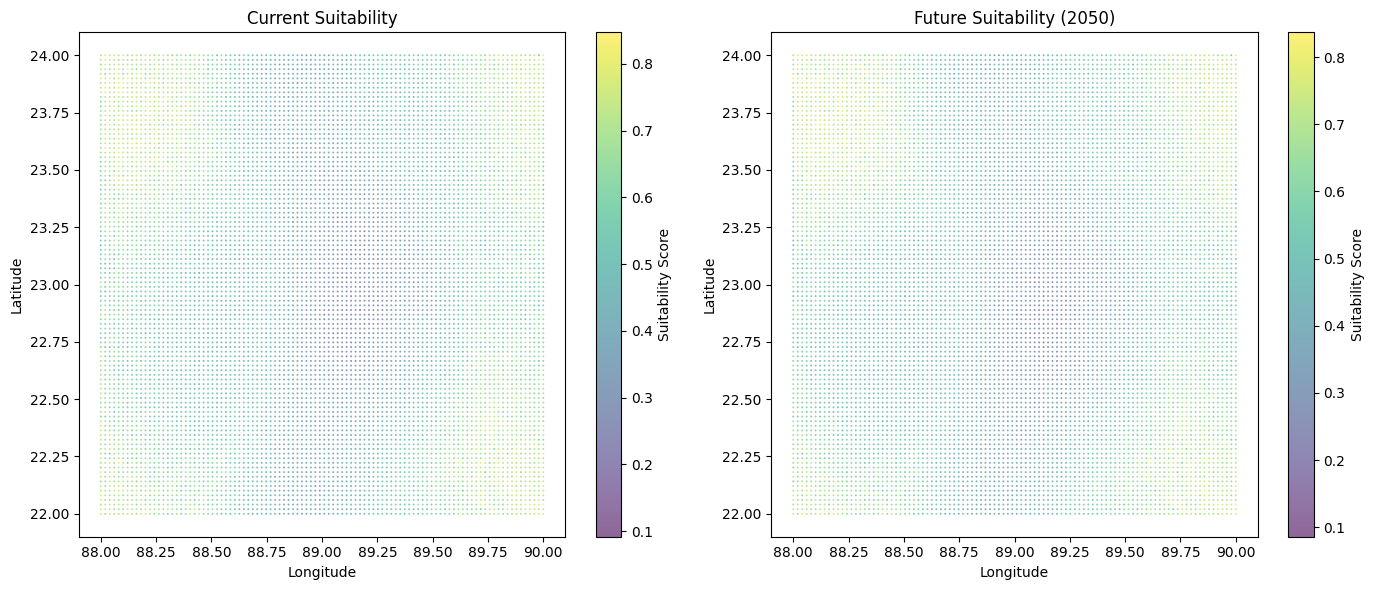

In [27]:
# Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
cols = ['elevation', 'irr_current', 'temp_current', 'suit_current', 'suit_future', 'dist_to_grid']
for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=30, edgecolor='k', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df[['elevation', 'irr_current', 'temp_current', 'dist_to_grid',
           'suit_current', 'suit_future']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix of Environmental Variables')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Maps of suitability
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sc1 = ax1.scatter(df['lon'], df['lat'], c=df['suit_current'], cmap='viridis',
                  s=2, alpha=0.6, edgecolors='none')
ax1.set_title('Current Suitability')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(sc1, ax=ax1, label='Suitability Score')

sc2 = ax2.scatter(df['lon'], df['lat'], c=df['suit_future'], cmap='viridis',
                  s=2, alpha=0.6, edgecolors='none')
ax2.set_title('Future Suitability (2050)')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
plt.colorbar(sc2, ax=ax2, label='Suitability Score')
plt.tight_layout()
plt.savefig('suitability_maps.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Hypothesis Test: Is the Change Significant?

We want to know if the difference between future and current suitability is big enough that it’s unlikely to be just random noise.

First we check if the differences follow a bell‑shaped curve (normal distribution). If they do, we can use a **paired t‑test**; if not, we use a safer **Wilcoxon signed‑rank test**.

Here the differences are **not** normal, so we use the Wilcoxon test. The result gives a p‑value – if it’s less than 0.05, we say the change is statistically significant.

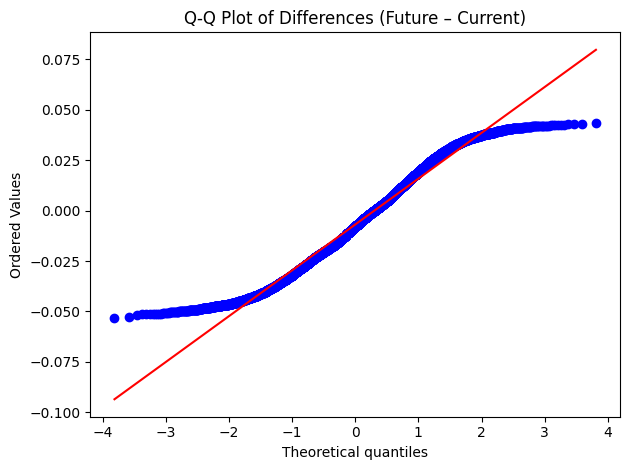

Shapiro–Wilk p-value (first 5000): 0.0000
Differences not normal. Using Wilcoxon signed‑rank test.

Test statistic: 16851152.0000, p-value: 0.0000
Reject H0: Significant change in suitability between current and future.


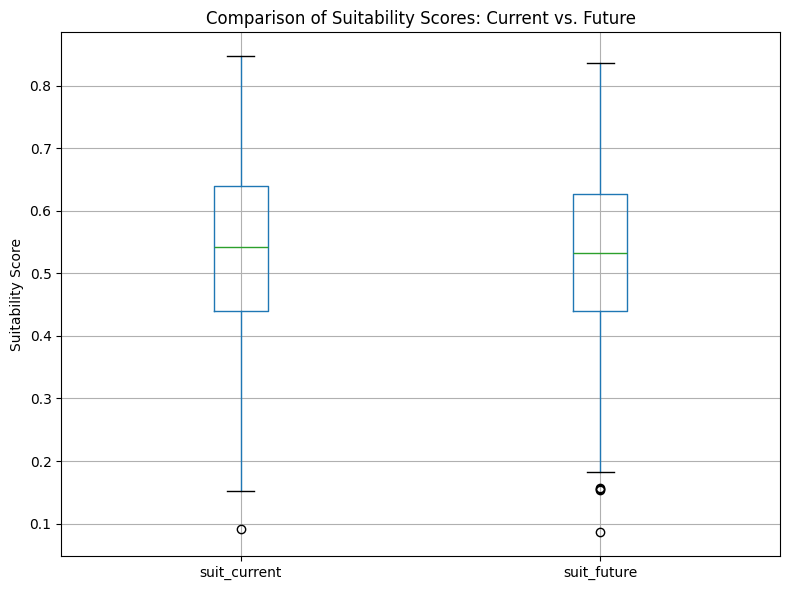

In [28]:
# Calculate the difference
diff = df['suit_future'] - df['suit_current']

# Q‑Q plot to check normality (points should follow the red line)
plt.figure()
stats.probplot(diff, dist="norm", plot=plt)
plt.title('Q‑Q Plot of Differences (Future – Current)')
plt.tight_layout()
plt.savefig('qqplot_diff.png', dpi=300, bbox_inches='tight')
plt.show()

# Shapiro–Wilk test for normality (on a subset because of sample size limit)
stat, p_shapiro = stats.shapiro(diff[:5000])
print(f'Shapiro–Wilk p-value (first 5000): {p_shapiro:.4f}')
if p_shapiro > 0.05:
    print("Differences appear normal. Using paired t‑test.")
    t_stat, p_val = stats.ttest_rel(df['suit_future'], df['suit_current'])
else:
    print("Differences not normal. Using Wilcoxon signed‑rank test.")
    t_stat, p_val = stats.wilcoxon(df['suit_future'], df['suit_current'])

print(f'\nTest statistic: {t_stat:.4f}, p-value: {p_val:.4f}')
if p_val < 0.05:
    print("Reject H0: Significant change in suitability between current and future.")
else:
    print("Fail to reject H0: No significant change detected.")

# Boxplot to visualise the shift
plt.figure(figsize=(8, 6))
df[['suit_current', 'suit_future']].boxplot()
plt.ylabel('Suitability Score')
plt.title('Comparison of Suitability Scores: Current vs. Future')
plt.tight_layout()
plt.savefig('boxplot_suitability.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. ANOVA: Does Land Cover Matter? Does Policy Zone Matter?

**One‑way ANOVA** tests whether the average future suitability is different across the five land cover types. If it is, we then do a **Tukey HSD** test to see exactly which pairs are different.

**Two‑way ANOVA** adds a second factor – policy zone – and also checks if there’s an **interaction** (i.e., does the effect of land cover depend on whether you’re in a policy zone?). An interaction plot helps visualise this.

One‑way ANOVA (landcover):
                  sum_sq      df           F         PR(>F)
C(landcover)    8.708271     4.0  146.082189  1.341644e-121
Residual      148.955828  9995.0         NaN            NaN

Tukey HSD Post‑hoc Test:
 group1  group2  meandiff  p-adj   lower   upper  reject
      0       1    0.0563 0.0000  0.0453  0.0673    True
      0       2    0.0781 0.0000  0.0667  0.0895    True
      0       3    0.1045 0.0000  0.0916  0.1173    True
      0       4    0.0348 0.0000  0.0189  0.0507    True
      1       2    0.0218 0.0000  0.0135  0.0301    True
      1       3    0.0482 0.0000  0.0380  0.0583    True
      1       4   -0.0215 0.0002 -0.0353 -0.0077    True
      2       3    0.0264 0.0000  0.0157  0.0370    True
      2       4   -0.0433 0.0000 -0.0574 -0.0291    True
      3       4   -0.0696 0.0000 -0.0850 -0.0543    True


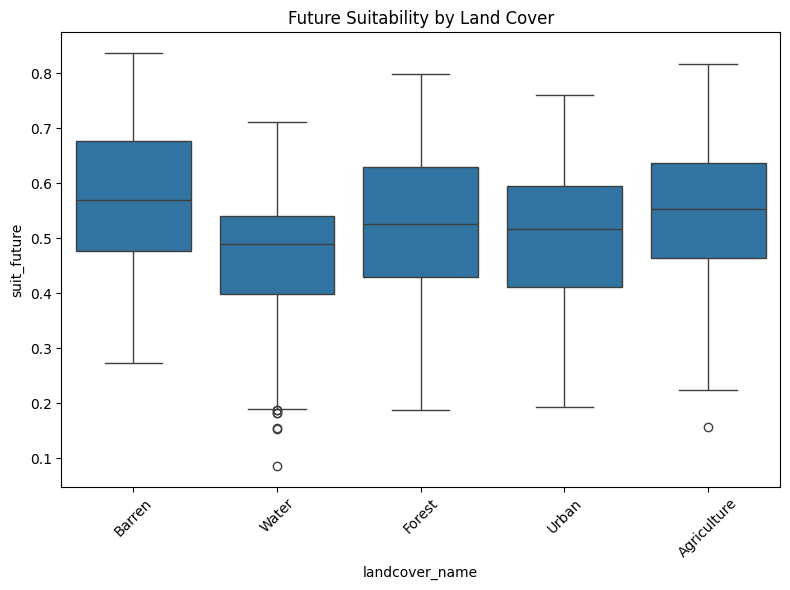


Two‑way ANOVA (landcover + policy_zone + interaction):
                                sum_sq      df            F         PR(>F)
C(landcover)                  8.935271     4.0   248.153027  1.447060e-203
C(policy_zone)               58.990385     1.0  6553.194638   0.000000e+00
C(landcover):C(policy_zone)   0.037710     4.0     1.047285   3.810725e-01
Residual                     89.927734  9990.0          NaN            NaN


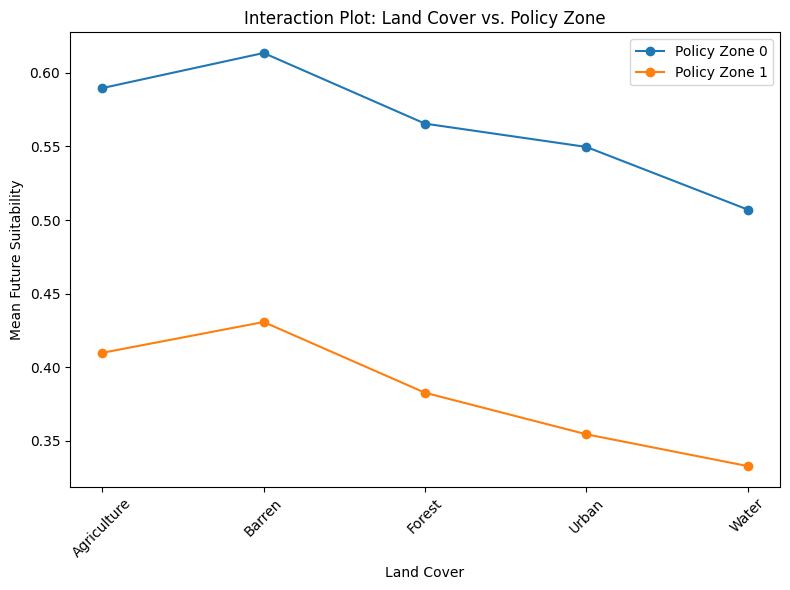

In [29]:
# One‑way ANOVA
anova1 = ols('suit_future ~ C(landcover)', data=df).fit()
anova_table1 = sm.stats.anova_lm(anova1, typ=2)
print("One‑way ANOVA (landcover):")
print(anova_table1)

# If significant, do Tukey HSD
if anova_table1['PR(>F)'][0] < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tukey = pairwise_tukeyhsd(endog=df['suit_future'], groups=df['landcover'], alpha=0.05)
    tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
    print("\nTukey HSD Post‑hoc Test:")
    print(tukey_df.to_string(index=False))

# Boxplot by land cover
plt.figure(figsize=(8, 6))
sns.boxplot(x='landcover_name', y='suit_future', data=df)
plt.title('Future Suitability by Land Cover')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('anova_landcover.png', dpi=300, bbox_inches='tight')
plt.show()

# Two‑way ANOVA with interaction
anova2 = ols('suit_future ~ C(landcover) + C(policy_zone) + C(landcover):C(policy_zone)',
             data=df).fit()
anova_table2 = sm.stats.anova_lm(anova2, typ=2)
print("\nTwo‑way ANOVA (landcover + policy_zone + interaction):")
print(anova_table2)

# Interaction plot
plt.figure(figsize=(8, 6))
for pz in [0, 1]:
    subset = df[df['policy_zone'] == pz]
    means = subset.groupby('landcover_name')['suit_future'].mean()
    plt.plot(means.index, means.values, marker='o', label=f'Policy Zone {pz}')
plt.xlabel('Land Cover')
plt.ylabel('Mean Future Suitability')
plt.title('Interaction Plot: Land Cover vs. Policy Zone')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('interaction_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Multiple Linear Regression

We build a model that predicts future suitability using all the environmental factors. The equation looks like:

**suit_future = constant + (effect of elevation) + (effect of irradiance) + ...**

We **standardise** the predictors (subtract mean, divide by standard deviation) so that their coefficients are directly comparable – a bigger absolute coefficient means a more important factor.

We also check:
- **VIF** (Variance Inflation Factor) – if VIF > 5, it means predictors are too correlated and we might have a problem.
- **Residual plots** – to see if the model assumptions hold.
- **Moran’s I** – to test if the leftover errors are clustered in space (they usually are, which we note as a limitation).

                            OLS Regression Results                            
Dep. Variable:            suit_future   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     8472.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:59:30   Log-Likelihood:                 15591.
No. Observations:               10000   AIC:                        -3.117e+04
Df Residuals:                    9993   BIC:                        -3.112e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5291      0.001   1039.216      0.0

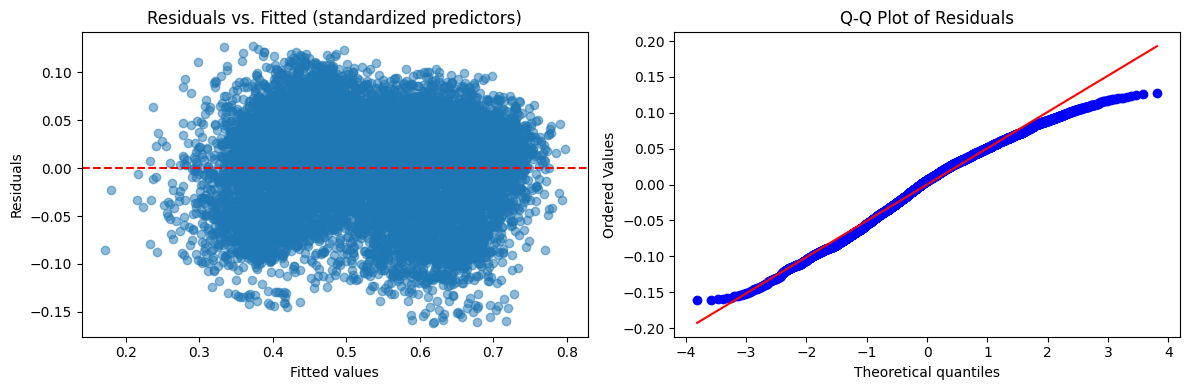


Moran's I for residuals: 0.8302, p-value: 0.0000
Significant spatial autocorrelation detected. This is common in gridded data and should be noted as a limitation.


In [30]:
# Define predictors and target
feature_cols = ['elevation', 'irr_current', 'temp_current', 'dist_to_grid', 'landcover', 'protected']
X = df[feature_cols]
y = df['suit_future']

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_const = sm.add_constant(X_scaled)  # add intercept

# Fit model
model_lr_scaled = sm.OLS(y, X_scaled_const).fit()
print(model_lr_scaled.summary())

# VIF (same as original because scaling doesn't affect VIF)
vif_data = pd.DataFrame()
vif_data['Variable'] = ['const'] + feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_scaled_const, i) for i in range(X_scaled_const.shape[1])]
print("\nVariance Inflation Factors (after standardization):")
print(vif_data)

# Residual plots
residuals = model_lr_scaled.resid
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(model_lr_scaled.fittedvalues, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (standardized predictors)')

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q‑Q Plot of Residuals')
plt.tight_layout()
plt.savefig('regression_diagnostics_standardized.png', dpi=300, bbox_inches='tight')
plt.show()

# Spatial autocorrelation test
if spatial_test_available:
    coords = list(zip(df['lon'], df['lat']))
    w = DistanceBand(coords, threshold=0.1, binary=True)  # ~10 km threshold
    w.transform = 'r'
    moran = Moran(residuals, w)
    print(f"\nMoran's I for residuals: {moran.I:.4f}, p-value: {moran.p_norm:.4f}")
    if moran.p_norm < 0.05:
        print("Significant spatial autocorrelation detected. This is common in gridded data and should be noted as a limitation.")
    else:
        print("No significant spatial autocorrelation in residuals.")
else:
    print("\nSpatial autocorrelation test skipped (libpysal/esda not installed).")

# 8. Logistic Regression & ROC Curve

Now we treat the problem as a simple **yes/no** question: is a location suitable (above‑median future suitability) or not?

We use **logistic regression**, which is designed for yes/no outcomes. Then we draw the **ROC curve** – a graph that shows how well the model separates suitable from unsuitable sites. The **AUC** (Area Under the Curve) tells us the model’s overall performance: 1.0 is perfect, 0.5 is no better than random. Here we get AUC = 0.952, which is excellent.

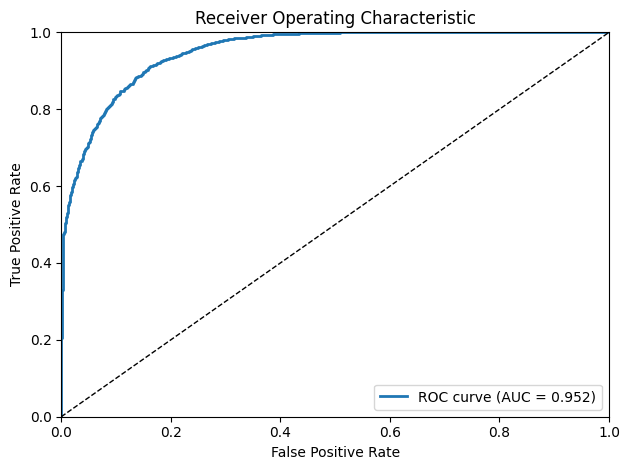


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1511
           1       0.87      0.88      0.87      1489

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000

Confusion Matrix:
[[1310  201]
 [ 185 1304]]


In [31]:
X_log = df[['elevation', 'irr_current', 'temp_current', 'dist_to_grid', 'landcover', 'protected']]
y_log = df['suitable_future_binary']

# Standardise
scaler_log = StandardScaler()
X_scaled_log = scaler_log.fit_transform(X_log)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled_log, y_log, test_size=0.3, random_state=42)

# Fit logistic regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Predict probabilities
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification report and confusion matrix
y_pred = logreg.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 9. Clustering: Finding Risk Zones

We want to group locations that are similar in their environmental conditions. This helps identify broad regions that might face similar climate risks.

We use **k‑means clustering**, which divides the data into `k` groups. We try different values of `k` and pick the one that gives the highest **silhouette score** (a measure of how well‑separated the groups are). Here, `k = 3` is best.

Then we look at the average characteristics of each cluster and map them.

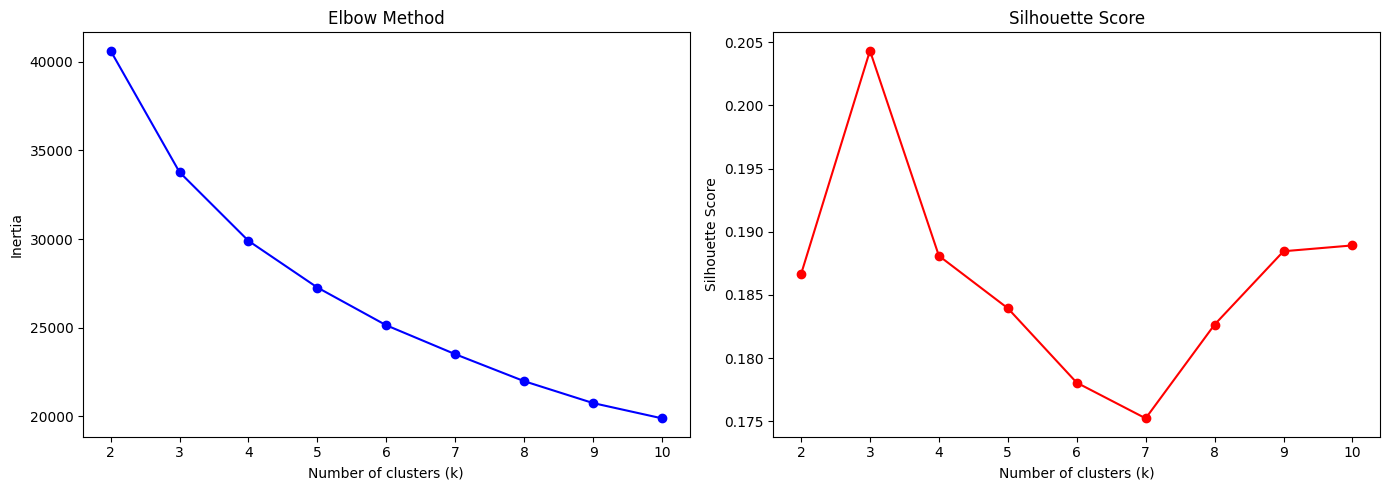

Optimal number of clusters (max silhouette): 3 (score: 0.204)
Note: Silhouette scores around 0.2 are common for environmental data due to gradual transitions; clusters still capture meaningful gradients.


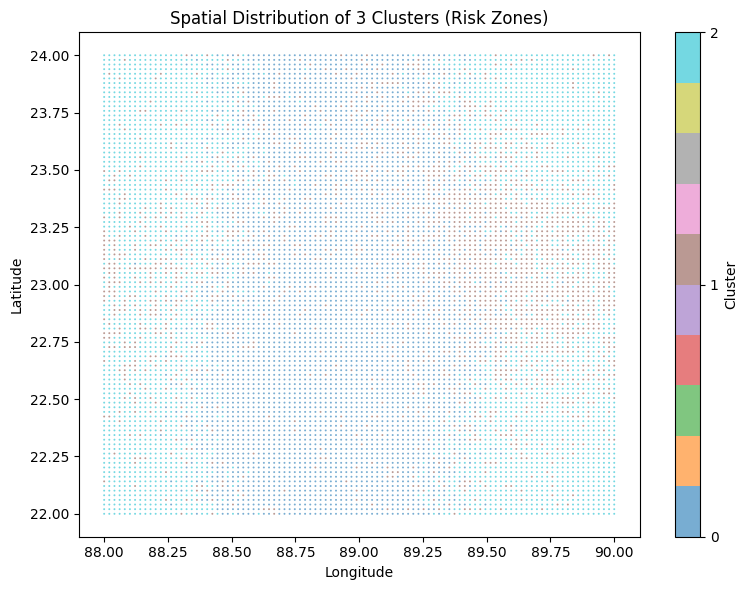


Cluster summary (mean values):
          elevation  irr_future  temp_future  suit_future
cluster                                                  
0        349.973091    4.116111    29.322494     0.447644
1        186.685436    4.818881    28.197623     0.478424
2        304.794431    5.750625    27.231518     0.645145


In [32]:
# Features for clustering
cluster_features = ['elevation', 'irr_future', 'temp_future', 'dist_to_grid', 'landcover']
X_cluster = df[cluster_features].copy()
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# Try different k values
inertia = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)
    sil = silhouette_score(X_cluster_scaled, kmeans.labels_)
    silhouette_scores.append(sil)

# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.savefig('cluster_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# Choose k with highest silhouette
k_opt = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (max silhouette): {k_opt} (score: {silhouette_scores[np.argmax(silhouette_scores)]:.3f})")
print("Note: Silhouette scores around 0.2 are common for environmental data due to gradual transitions; clusters still capture meaningful gradients.")

# Fit final k‑means
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Map the clusters
plt.figure(figsize=(8, 6))
sc = plt.scatter(df['lon'], df['lat'], c=df['cluster'], cmap='tab10', s=2, alpha=0.6, edgecolors='none')
plt.colorbar(sc, ticks=range(k_opt), label='Cluster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Spatial Distribution of {k_opt} Clusters (Risk Zones)')
plt.tight_layout()
plt.savefig('cluster_map.png', dpi=300, bbox_inches='tight')
plt.show()

# Characterise each cluster
cluster_summary = df.groupby('cluster')[['elevation', 'irr_future', 'temp_future', 'suit_future']].mean()
print("\nCluster summary (mean values):")
print(cluster_summary)

# 10. Decision Tree: Simple Rules for Everyone

A decision tree is like a flow chart: it asks a series of yes/no questions (e.g., “is irradiance > 4.9?”) and ends with a predicted suitability value. It’s very easy to understand, even for non‑experts.

We limit the tree to a depth of 3 so it doesn’t become too complicated. The tree shows that **irradiance** is by far the most important factor. The final rules can be used by planners to quickly screen locations.

Train R²: 0.739
Test R²: 0.730
Cross‑validation R²: 0.511 ± 0.050

Feature importances:
  irr_current: 0.902
  temp_current: 0.098
  landcover: 0.000
  protected: 0.000
  dist_to_grid: 0.000
  elevation: 0.000


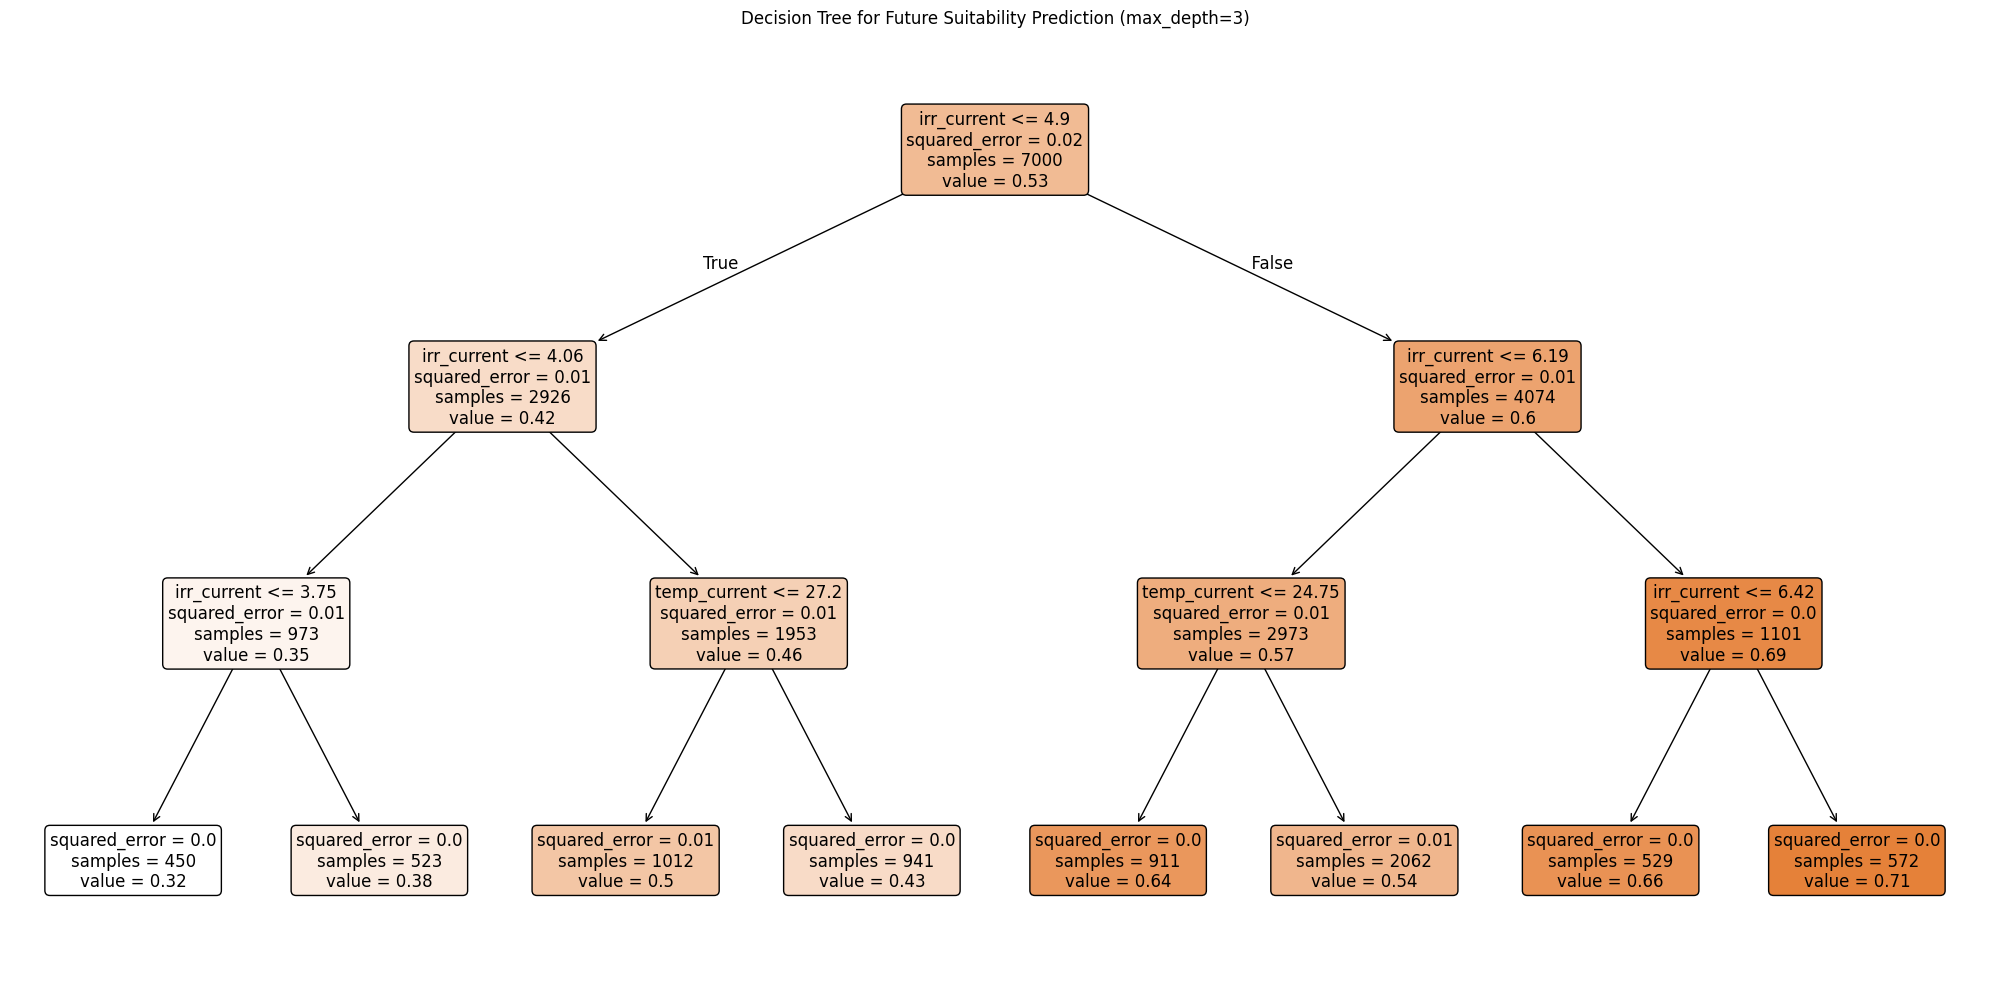


Decision tree rules (text form):
|--- irr_current <= 4.90
|   |--- irr_current <= 4.06
|   |   |--- irr_current <= 3.75
|   |   |   |--- value: [0.32]
|   |   |--- irr_current >  3.75
|   |   |   |--- value: [0.38]
|   |--- irr_current >  4.06
|   |   |--- temp_current <= 27.20
|   |   |   |--- value: [0.50]
|   |   |--- temp_current >  27.20
|   |   |   |--- value: [0.43]
|--- irr_current >  4.90
|   |--- irr_current <= 6.19
|   |   |--- temp_current <= 24.75
|   |   |   |--- value: [0.64]
|   |   |--- temp_current >  24.75
|   |   |   |--- value: [0.54]
|   |--- irr_current >  6.19
|   |   |--- irr_current <= 6.42
|   |   |   |--- value: [0.66]
|   |   |--- irr_current >  6.42
|   |   |   |--- value: [0.71]



In [33]:
X_tree = df[['elevation', 'irr_current', 'temp_current', 'dist_to_grid', 'landcover', 'protected']]
y_tree = df['suit_future']

# Train/test split
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree, test_size=0.3, random_state=42)

# Fit tree (max depth 3 for readability)
tree = DecisionTreeRegressor(max_depth=3, min_samples_split=50, random_state=42)
tree.fit(X_train_tree, y_train_tree)

# Evaluate
print(f"Train R²: {tree.score(X_train_tree, y_train_tree):.3f}")
print(f"Test R²: {tree.score(X_test_tree, y_test_tree):.3f}")

# Cross‑validation
cv_scores = cross_val_score(tree, X_tree, y_tree, cv=5, scoring='r2')
print(f"Cross‑validation R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Feature importance
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]
print("\nFeature importances:")
for i in indices:
    print(f"  {X_tree.columns[i]}: {importances[i]:.3f}")

# Plot tree
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X_tree.columns, filled=True, rounded=True, fontsize=12, precision=2)
plt.title('Decision Tree for Future Suitability Prediction (max_depth=3)')
plt.tight_layout()
plt.savefig('decision_tree_clean.png', dpi=300, bbox_inches='tight')
plt.show()

# Print rules as text
from sklearn.tree import export_text
tree_rules = export_text(tree, feature_names=list(X_tree.columns))
print("\nDecision tree rules (text form):")
print(tree_rules)

# 11. Summary and Reproducibility

We save the final dataset and print the key numbers from our analysis. All figures have been saved as high‑resolution PNG files, ready to be used in a paper or presentation.

In [34]:
# Save DataFrame to CSV
df.to_csv('solar_suitability_results.csv', index=False)
print("Results saved to solar_suitability_results.csv")

# Print key findings
print("\n=== Key Findings ===")
print(f"1. Suitability change p‑value: {p_val:.4f} – {'Significant' if p_val < 0.05 else 'Not significant'}")
print(f"2. Linear regression R² (standardized): {model_lr_scaled.rsquared:.3f}")
print(f"3. Logistic regression AUC: {roc_auc:.3f}")
print(f"4. Optimal clusters (k): {k_opt} (silhouette score: {silhouette_scores[np.argmax(silhouette_scores)]:.3f})")
print(f"5. Decision tree test R²: {tree.score(X_test_tree, y_test_tree):.3f}")
print(f"6. Most important feature (tree): {X_tree.columns[indices[0]]} ({importances[indices[0]]:.3f})")
if spatial_test_available:
    print(f"7. Moran's I for residuals: {moran.I:.4f} (p={moran.p_norm:.4f}) – spatial autocorrelation present.")

Results saved to solar_suitability_results.csv

=== Key Findings ===
1. Suitability change p‑value: 0.0000 – Significant
2. Linear regression R² (standardized): 0.836
3. Logistic regression AUC: 0.952
4. Optimal clusters (k): 3 (silhouette score: 0.204)
5. Decision tree test R²: 0.730
6. Most important feature (tree): irr_current (0.902)
7. Moran's I for residuals: 0.8302 (p=0.0000) – spatial autocorrelation present.


# 12. How to Use This Study with Real Data

To apply the same analysis to real‑world data, simply **replace the data generation part (Section 2)** with code that loads your own datasets. Here are some free sources for India:

- **Solar radiation**: [Global Solar Atlas](https://globalsolaratlas.info) – download GeoTIFF.
- **Temperature (current & future)**: [WorldClim](https://worldclim.org) – download CMIP6 projections.
- **Elevation**: SRTM via the `elevation` Python package.
- **Land cover**: [ESA CCI](https://www.esa-landcover-cci.org).
- **Protected areas**: [WDPA](https://www.protectedplanet.net).
- **Distance to grid**: Use OSMnx to get transmission lines or major roads, then compute distance.

After loading, make sure all rasters are aligned to the same grid, handle missing values, and then proceed with Sections 3–11. The rest of the notebook will work exactly the same way.